In [4]:
import matplotlib as mpl
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt

# 下載繁體中文字型
!wget -O SourceHanSerifTW-VF.ttf https://github.com/adobe-fonts/source-han-serif/raw/release/Variable/TTF/Subset/SourceHanSerifTW-VF.ttf

# 加入字型檔
fm.fontManager.addfont('SourceHanSerifTW-VF.ttf')

# 設定字型
#
mpl.rc('font', family='Source Han Serif TW VF')

--2026-03-11 08:28:22--  https://github.com/adobe-fonts/source-han-serif/raw/release/Variable/TTF/Subset/SourceHanSerifTW-VF.ttf
Resolving github.com (github.com)... 140.82.112.4
Connecting to github.com (github.com)|140.82.112.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/adobe-fonts/source-han-serif/release/Variable/TTF/Subset/SourceHanSerifTW-VF.ttf [following]
--2026-03-11 08:28:22--  https://raw.githubusercontent.com/adobe-fonts/source-han-serif/release/Variable/TTF/Subset/SourceHanSerifTW-VF.ttf
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 16851180 (16M) [application/octet-stream]
Saving to: ‘SourceHanSerifTW-VF.ttf’

SourceHanSerifTW-VF 100%[===================>]  16.07M  --.-KB/s

In [5]:
import yfinance as yf
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

正在下載資料...


/tmp/ipykernel_554/3311592335.py:29: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(list(tickers.values()), period="5y")['Close']
[*********************100%***********************]  4 of 4 completed



--- 日級別 (Daily) 相關性矩陣 ---
Ticker      0050    00631L     00662    00865B
Ticker                                        
0050    1.000000  0.971047  0.662527 -0.306666
00631L  0.971047  1.000000  0.657525 -0.290828
00662   0.662527  0.657525  1.000000 -0.120190
00865B -0.306666 -0.290828 -0.120190  1.000000


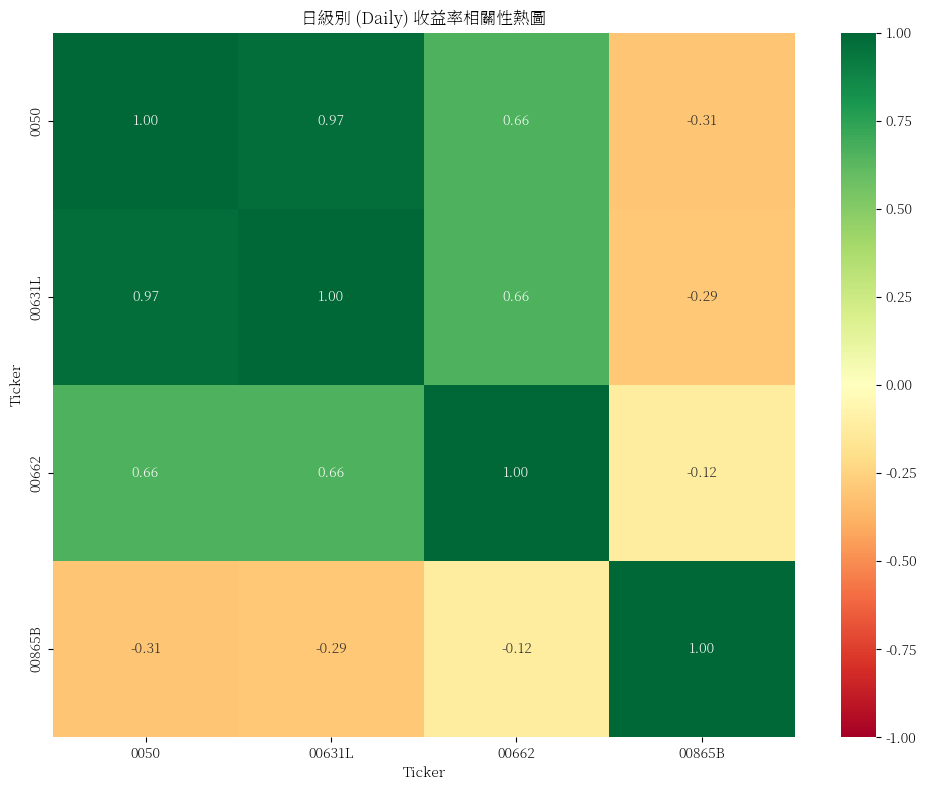


--- 月級別 (Monthly) 相關性矩陣 ---
Ticker      0050    00631L     00662    00865B
Ticker                                        
0050    1.000000  0.975459  0.492838 -0.439090
00631L  0.975459  1.000000  0.538538 -0.431644
00662   0.492838  0.538538  1.000000 -0.093936
00865B -0.439090 -0.431644 -0.093936  1.000000


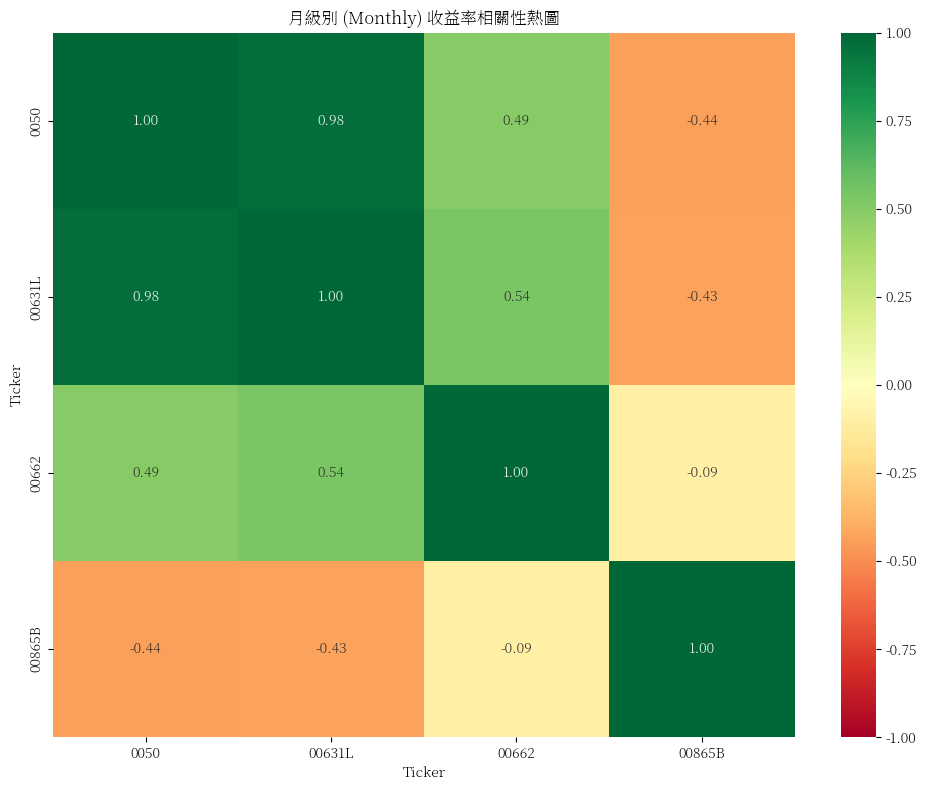


分析完成，資料已保存至 daily_prices.csv 與 monthly_prices.csv


In [9]:
# 解決 matplotlib 中文顯示問題 (針對不同作業系統可做調整)
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei']
plt.rcParams['axes.unicode_minus'] = False

def get_asset_data():
    # 定義標的代碼 (Yahoo Finance 格式)
    # QQQ: 納斯達克100
    # QLD: 2倍做多納斯達克100
    # SGOV: 0-3個月超短期美債 (避險/現金替代)

    # 00662: 納斯達克100
    # 0050: 元大台灣50
    # 00631L: 元大台灣50正2 (2倍槓桿)
    # 00865B: 國泰美債20年
    tickers = {
        # "QQQ": "QQQ",
        # "QLD": "QLD",
        # "SGOV": "SGOV",

        "00662": "00662.TW",
        "0050": "0050.TW",
        "00631L": "00631L.TW",
        "00865B": "00865B.TW"
    }

    print("正在下載資料...")
    # 下載近五年的歷史資料
    # 注意：部分槓桿型或新發行 ETF 若資料不滿五年，dropna 會縮短分析區間
    data = yf.download(list(tickers.values()), period="5y")['Close']

    # 將欄位名稱改回易讀的名稱
    inv_tickers = {v: k for k, v in tickers.items()}
    data = data.rename(columns=inv_tickers)

    # 移除缺失值 (處理各國股市開盤時間不一致或上市日期不同的問題)
    data = data.dropna()

    return data

def analyze_correlation(df, frequency="Daily"):
    # 計算百分比收益率 (Returns) 進行相關性分析
    returns = df.pct_change().dropna()

    # 計算相關係數矩陣
    corr_matrix = returns.corr()

    print(f"\n--- {frequency} 相關性矩陣 ---")
    print(corr_matrix)

    # 繪製熱圖 (Heatmap)
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, annot=True, cmap='RdYlGn', vmin=-1, vmax=1, center=0, fmt=".2f")
    plt.title(f"{frequency} 收益率相關性熱圖")
    plt.tight_layout()
    plt.show()

def main():
    # 1. 取得日收盤價資料
    daily_data = get_asset_data()

    if daily_data.empty:
        print("錯誤：無法取得足夠的資料進行分析。")
        return

    # 2. 轉換為月收盤價資料 (取每個月最後一個交易日)
    monthly_data = daily_data.resample('ME').last()

    # 3. 進行日相關性分析
    analyze_correlation(daily_data, "日級別 (Daily)")

    # 4. 進行月相關性分析
    analyze_correlation(monthly_data, "月級別 (Monthly)")

    # 保存資料至 CSV 備查
    daily_data.to_csv("daily_prices.csv")
    monthly_data.to_csv("monthly_prices.csv")
    print("\n分析完成，資料已保存至 daily_prices.csv 與 monthly_prices.csv")

if __name__ == "__main__":
    main()